In [1]:
import numpy as np
import sys
sys.path.append('../')

In [2]:
from Regression import Regression

In [3]:
M1 = np.loadtxt('../matrices/M1.txt') # 2 min mid-quote
M2 = np.loadtxt('../matrices/M2.txt') # V
M3 = np.loadtxt('../matrices/M3.txt') # Arrival Price
M4 = np.loadtxt('../matrices/M4.txt') # X
M5 = np.loadtxt('../matrices/M5.txt') # VWAP 930 - 330 = S_tilda
M6 = np.loadtxt('../matrices/M6.txt') # VWAP 930 - 400
M7 = np.loadtxt('../matrices/M7.txt') # Terminal Price

In [4]:
reg = Regression(M1, M2, M3, M4, M5, M6, M7)

In [5]:
# cutoff_list = [ii for ii in range(10, 200)]

In [6]:
# d = {}
# for c in cutoff_list:
#     reg.cleanMatrices(reg.matrices, cutoff=c)
# # print(np.array(reg.cleanedMatrices).shape)
#     eta, beta = reg.getRegressionResults()
#     d[str(c)] = (eta, beta)

In [7]:
# d

In [8]:
# reg.cleanMatrices(reg.matrices, cutoff=40)
# print(np.array(reg.cleanedMatrices).shape)
# print(reg.faultyIdxList)

# Output regression results

In [9]:
eta, beta = reg.getRegressionResults()
eta, beta

(2.7888243693811527, 0.5450744771271434)

# Bootstrapped Significance Test --Residual

In [10]:
# count is the number of bootstrapped etas and betas
# the current count = 10000, which makes this cell runs a bit while
res = reg.getSignificanceTestResults(10000)

In [11]:
# t eta, t beta, pval for t eta, pval for t beta
t_eta_resid, t_beta_resid, t_eta_resid_paval, t_beta_resid_pval = res[0]
t_eta_resid, t_beta_resid, t_eta_resid_paval, t_beta_resid_pval

(1.7567919038210407,
 1.3387826477887075,
 0.07896430414808588,
 0.18065239928940427)

In [12]:
t_eta_resid_paval, t_beta_resid_pval

(0.07896430414808588, 0.18065239928940427)

# Bootstrapped Significance Test -- Paired

In [13]:
# t eta, t beta, pval for t eta, pval for t beta
t_eta_paired, t_beta_paired, t_eta_paired_paval, t_beta_paired_pval = res[1]
t_eta_paired, t_beta_paired, t_eta_paired_paval, t_beta_paired_pval

(2.333847823190984,
 3.884360547033785,
 0.0196107863635165,
 0.00010283727846812278)

In [14]:
text = ('eta             = '+str(eta)+ '\n'+
        't_eta_residual  = '+str(t_eta_resid)+'\n'+
        't_eta_paired    = '+str(t_eta_paired)+'\n'+
        'beta            = '+str(beta)+'\n'+
        't_beta_residual = '+str(t_beta_resid)+'\n'+
        't_beta_paired   = '+str(t_beta_paired))

In [15]:
t_eta_paired_paval, t_beta_paired_pval

(0.0196107863635165, 0.00010283727846812278)

In [16]:
print(text)

eta             = 2.7888243693811527
t_eta_residual  = 1.7567919038210407
t_eta_paired    = 2.333847823190984
beta            = 0.5450744771271434
t_beta_residual = 1.3387826477887075
t_beta_paired   = 3.884360547033785


In [17]:
text_file = open("../params_part1.txt", "w")
n = text_file.write(text)
text_file.close()

# Analysis of Residual

-----------------------------------------------------

Test if the residuals are homoskedastic
The p value: 0.0011486854546298934
The null hypothesis can be rejected
Conclusion: the residuals are heteroskedastic
-----------------------------------------------------

Test if the residuals are independent
The t statistic: 1.1904557023363522
The residuals are not independent
-----------------------------------------------------

Test if the residuals have mean zero
The p value:  0.49018960362127434
The null hypothesis cannot be rejected
The mean is zero.
-----------------------------------------------------

Test if the residuals are normally distributed
The p value: 0.0
The null hypothesis can be rejected
The residues does not follow a normal distribution.
This is a violation of the assumptions of non-linear regression


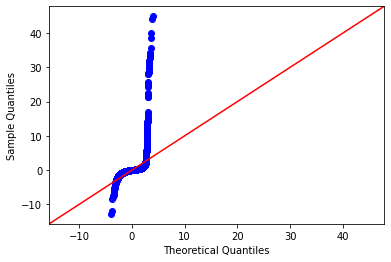

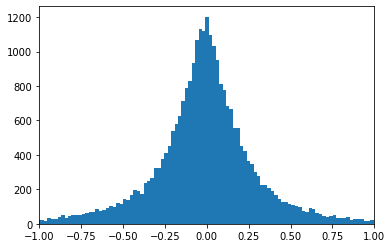

In [18]:
reg.getResidualAnalysis()

# Active and Inactive Stocks Parameters Comparison

In [19]:
out = reg.getActivityAnalysis()
print('active stocks')
print('eta   =', out[0][0])
print('beta  =', out[0][1])
print('\ninactive stocks')
print('eta   =', out[1][0])
print('beta  =', out[1][1])

active stocks
eta   = 10.582940713102841
beta  = 0.8665388106501389

inactive stocks
eta   = 1.621796912980813
beta  = 0.5875339633468607
